## Exercise - SVM for classification of 2 classes

> 1. Replicate the example from the slides, but using the `make_moons` instead of the `make_circles` dataset. That is, replace `from sklearn.datasets import make_circles` with `from sklearn.datasets import make_moons` and use this new function to generate $\texttt{X}$ and $\texttt{y}$. Then, check how the linear, polynomial, and radial basis function performs on this new dataset (by calculating and reporting their test accuracies).
> 2. The default setting for $C$, the regularization parameter, is $1$. Try to adjust this (both up and down) and see how the performance of your models changes.
> 3. Try to split your training data (again using `train_test_split`) to obtain a validation set. Try to tune your `polynomial` SVM (by changing the degree of the kernel and C) to obtain the best model on your validation data. Apply this model to your test data. Did you improve your model"s performance on the test data?

### Exercise 1

Replicate the example from the slides, but using the make_moons instead of the `make_circles` dataset. That is, replace `from sklearn.datasets import make_circles` with `from sklearn.datasets import make_moons` and use this new function to generate $\texttt{X}$ and $\texttt{y}$. Then, check how the linear, polynomial, and radial basis function performs on this new dataset (by calculating and reporting their test accuracies).

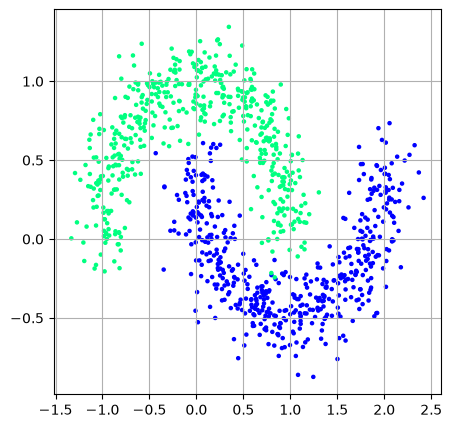

In [6]:
from sklearn import svm
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples = 1000, noise = 0.15, random_state = 42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

fig = plt.figure(figsize = ([5,5]))

plt.scatter(X[:, 0], X[:, 1], s = 5, c = y, cmap = plt.get_cmap("winter_r"))
plt.grid()
plt.show()

In [ ]:
svm_linear = svm.SVC(kernel = "linear")
svm_linear.fit(X_train, y_train)

y_test_hat_linear = svm_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_test_hat_linear) 

print(f"Linear SVM achieved {round(accuracy_linear * 100, 1)}% accuracy.")

Linear SVM achieved 85.5% accuracy.


In [8]:
svm_poly = svm.SVC(kernel = "poly", degree = 2)
svm_poly.fit(X_train, y_train)

y_test_hat_poly = svm_poly.predict(X_test)
accuracy_poly = accuracy_score(y_test, y_test_hat_poly)

print(f"Polynomial SVM achieved {round(accuracy_poly * 100, 1)}% accuracy.")

Polynomial SVM achieved 80.5% accuracy.


In [9]:
svm_rbf = svm.SVC(kernel="rbf", C = 10)
svm_rbf.fit(X_train, y_train)

y_test_hat_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_test_hat_rbf)

print(f"Radial SVM achieve {round(accuracy_rbf * 100, 1)}% accuracy.")

Radial SVM achieve 100.0% accuracy.


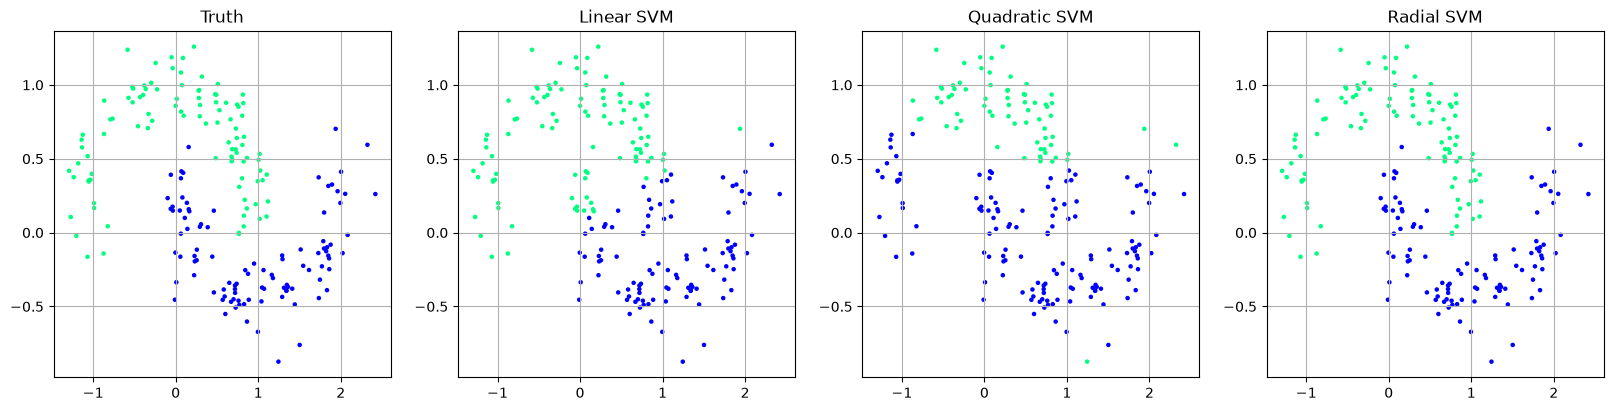

In [19]:
panels = [
    ("Truth", y_test),
    ("Linear SVM", y_test_hat_linear),
    ("Quadratic SVM", y_test_hat_poly),
    ("Radial SVM", y_test_hat_rbf),
]

fig = plt.figure(figsize = (20, 4.5))
for i, (title, labels) in enumerate(panels):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.scatter(X_test[:, 0], X_test[:, 1], s = 5, c = labels, cmap = plt.get_cmap("winter_r"))
    plt.title(title)
    plt.grid()

plt.show()

## Exercise 2

> 1. The default setting for $C$, the regularization parameter, is $1$. Try to adjust this (both up and down) and see how the performance of your models changes.
> 2. I suggest using $0.01$ for the low value and $100$ for the high value, but you decide.
> 3. Perhaps do it just for the polynomial and the RBF kernels.

In [ ]:
svm_poly_low_C = svm.SVC(kernel="poly", degree=4, C=0.01)
svm_poly_high_C = svm.SVC(kernel="poly", degree=4, C=100)

svm_poly_low_C.fit(X_train, y_train)
svm_poly_high_C.fit(X_train, y_train)

y_test_hat_poly_low_C = svm_poly_low_C.predict(X_test)
y_test_hat_poly_high_C = svm_poly_high_C.predict(X_test)

accuracy_poly_low_C = accuracy_score(y_test, y_test_hat_poly_low_C)
accuracy_poly_high_C = accuracy_score(y_test, y_test_hat_poly_high_C)

print(f"Polynomial SVM with low C achieved {round(accuracy_poly_low_C * 100, 1)}% accuracy.")
print(f"Polynomial SVM with high C achieved {round(accuracy_poly_high_C * 100, 1)}% accuracy.")

Polynomial SVM with low C achieved 68.0% accuracy.
Polynomial SVM with high C achieved 81.0% accuracy.


In [21]:
svm_rbf_low_C = svm.SVC(kernel="rbf", C=0.01)
svm_rbf_high_C = svm.SVC(kernel="rbf", C=100)

svm_rbf_low_C.fit(X_train, y_train)
svm_rbf_high_C.fit(X_train, y_train)

y_test_hat_rbf_low_C = svm_rbf_low_C.predict(X_test)
y_test_hat_rbf_high_C = svm_rbf_high_C.predict(X_test)

accuracy_rbf_low_C = accuracy_score(y_test, y_test_hat_rbf_low_C)
accuracy_rbf_high_C = accuracy_score(y_test, y_test_hat_rbf_high_C)

print(f"RBF SVM with low C achieved {round(accuracy_rbf_low_C * 100, 1)}% accuracy.")
print(f"RBF SVM with high C achieved {round(accuracy_rbf_high_C * 100, 1)}% accuracy.")

RBF SVM with low C achieved 88.0% accuracy.
RBF SVM with high C achieved 100.0% accuracy.


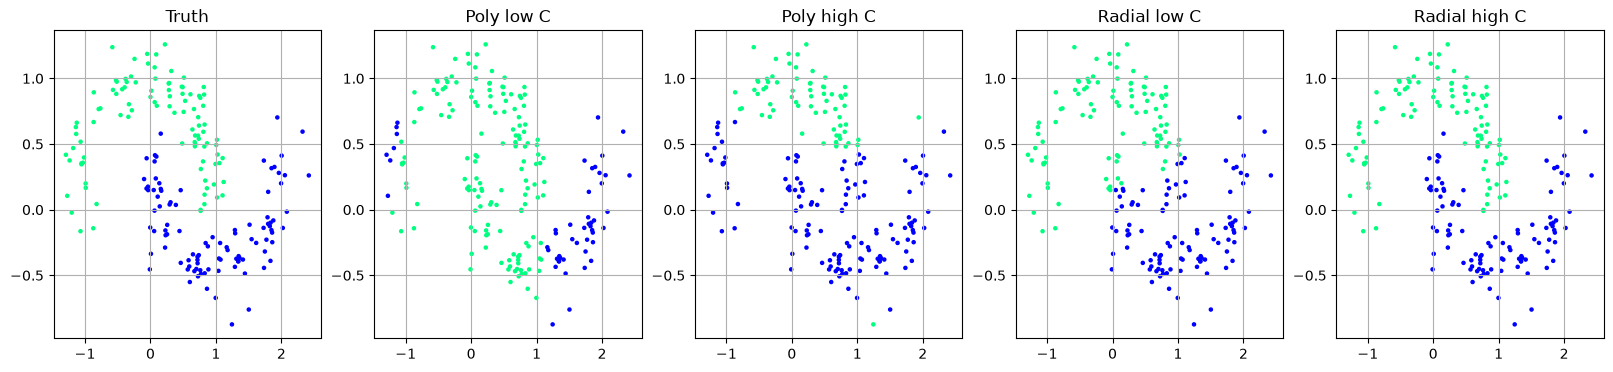

In [24]:
panels = [
    ("Truth", y_test),
    ("Poly low C", y_test_hat_poly_low_C),
    ("Poly high C", y_test_hat_poly_high_C),
    ("Radial low C", y_test_hat_rbf_low_C),
    ("Radial high C", y_test_hat_rbf_high_C),
]

fig = plt.figure(figsize = (20, 4))
for i, (title, labels) in enumerate(panels):
    ax = fig.add_subplot(1, 5, i + 1)
    ax.scatter(X_test[:, 0], X_test[:, 1], s = 5, c = labels, cmap = plt.get_cmap("winter_r"))

    plt.title(title)
    plt.grid()
    
plt.show()

### Exercise 3

> 1. Try to split your training data (again using `train_test_split`) to obtain a validation set. Try to tune your `polynomial` SVM (by changing the degree of the kernel and C) to obtain the best model on your validation data. Apply this model to your test data. Did you improve your model's performance on the test data?

In [26]:
import numpy as np
import pandas as pd

In [25]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)

In [31]:
poly_degrees = [2, 3, 4, 5, 6]
Cs = [0.001, 0.01, 1, 10, 100]

results = []

for degree in poly_degrees:
    for C in Cs:
        svm_poly = svm.SVC(kernel="poly", degree=degree, C=C)
        svm_poly.fit(X_train, y_train)
        y_val_hat = svm_poly.predict(X_val)
        accuracy = accuracy_score(y_val, y_val_hat)

        results.append([accuracy, degree, C])

results = pd.DataFrame(results)
results.columns = ["Accuracy", "Polynomial degree", "C"]

display(results)

,Accuracy,Polynomial degree,C
0,0.58750,2,0.001
1,0.74375,2,0.010
2,0.81875,2,1.000
3,0.83750,2,10.000
4,0.83750,2,100.000
5,0.72500,3,0.001
6,0.81250,3,0.010
7,0.92500,3,1.000
8,0.91875,3,10.000
9,0.91875,3,100.000


In [32]:
results[results["Accuracy"] == results["Accuracy"].max()]

,Accuracy,Polynomial degree,C
7,0.925,3,1.0


In [35]:
svm_poly_best = svm.SVC(kernel = "poly", degree = 3, C = 1)
svm_poly_best.fit(np.concatenate([X_train, X_val]), np.concatenate([y_train, y_val]))

y_pred_hat_poly_best = svm_poly_best.predict(X_test)

accuracy_poly_best = accuracy_score(y_test, y_pred_hat_poly_best)
print(f"Optimized polynomial SVM achieved {round(accuracy_poly_best * 100, 1)}% accuracy.")

Optimized polynomial SVM achieved 91.0% accuracy.


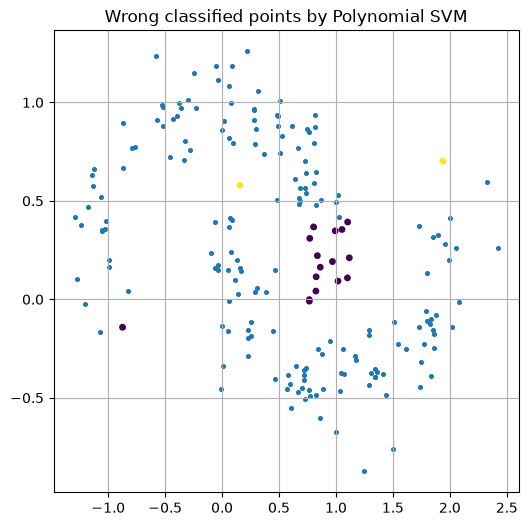

In [56]:
y_wrong = np.where(y_pred_hat_poly_best != y_test)[0]

fig = plt.figure(figsize = (6,6))

plt.scatter(X_test[:, 0], X_test[:, 1], s = 7)
plt.scatter(X_test[y_wrong, 0], X_test[y_wrong, 1], s = 15, c = y_test[y_wrong])
plt.title("Wrong classified points by Polynomial SVM")
plt.grid()
plt.show()

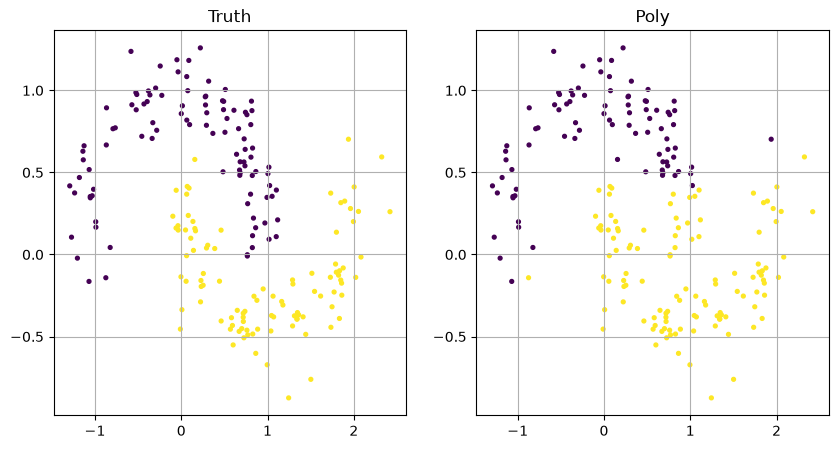

In [62]:
panels = [
    ("Truth", y_test),
    ("Poly", y_pred_hat_poly_best)
]

fig = plt.figure(figsize = (10,5))
for i, (title, labels) in enumerate(panels):
    ax = fig.add_subplot(1, 2, i + 1)
    ax.scatter(X_test[:, 0], X_test[:, 1], s = 7.5, c = labels)
    ax.set_title(title)
    plt.grid()

plt.show()